[stellar dataset on kaggle](https://www.kaggle.com/datasets/fedesoriano/stellar-classification-dataset-sdss17)

# 1- read & understand dataset
# 2- explore data
# 3- preprocesssing data
* > 1- feature selection
* > 2- maping to target col
* > 3- split data
* > 4- scaling data (standerd scaler)
# 4- design NN
# 5- prepartion NN to traning
# 6- traning NN
# 7- evalution model

1- `read & understand dataset`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input , Dense ,Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import sparse_categorical_crossentropy
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.regularizers import l1_l2
import warnings
warnings.filterwarnings("ignore")

In [2]:
dataset = pd.read_csv('star_classification_data.csv')
dataset.head()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


In [3]:
dataset.columns

Index(['obj_ID', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'run_ID',
       'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'class', 'redshift',
       'plate', 'MJD', 'fiber_ID'],
      dtype='object')

In [4]:
dataset.shape

(100000, 18)

<Axes: >

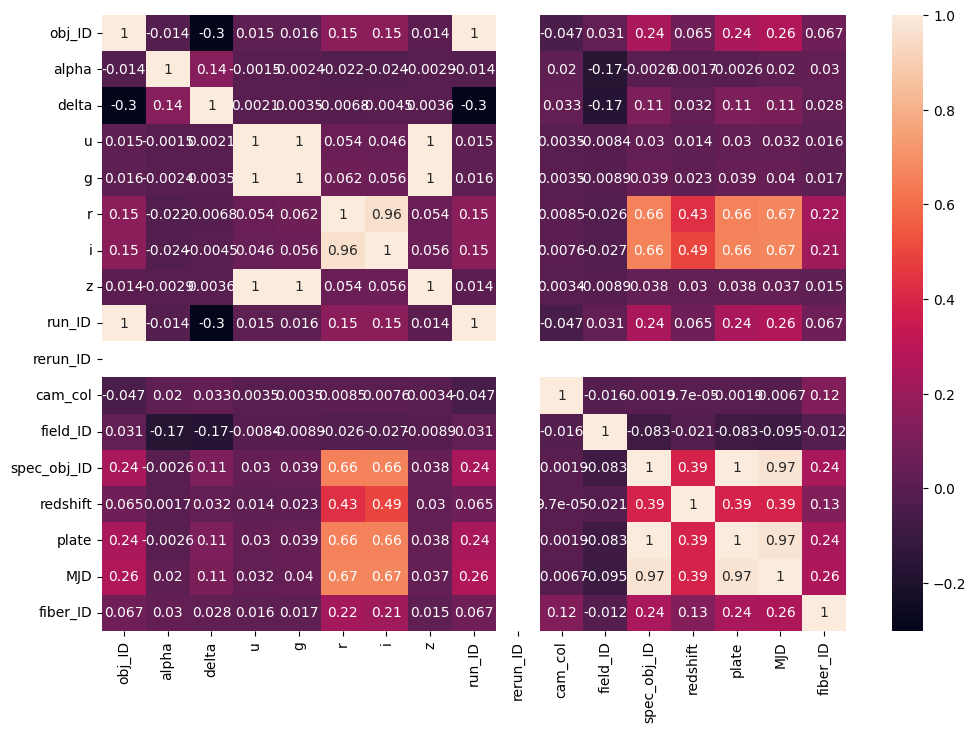

In [5]:
plt.figure(figsize=(12,8)) 
datset_num = dataset.select_dtypes(include=np.number)
sns.heatmap(datset_num.corr() ,annot=True)

       u      g      r      i      z
u  1.000  0.999  0.054  0.046  0.998
g  0.999  1.000  0.062  0.056  0.999
r  0.054  0.062  1.000  0.963  0.054
i  0.046  0.056  0.963  1.000  0.056
z  0.998  0.999  0.054  0.056  1.000


<Axes: >

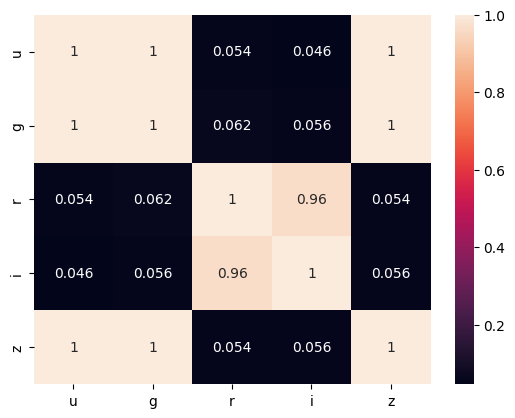

In [6]:
corr = dataset[['u','g','r','i','z']].corr()
print(corr.round(3))
sns.heatmap(corr , annot=True)

# 2- explore data

In [7]:
(dataset['u'] == dataset['g']).all()
(dataset['u'] == dataset['z']).all()

np.False_

In [9]:
print(dataset[['u','g','z']].describe())
print(dataset[['u','g','z']].nunique())

                   u              g              z
count  100000.000000  100000.000000  100000.000000
mean       21.980468      20.531387      18.668810
std        31.769291      31.750292      31.728152
min     -9999.000000   -9999.000000   -9999.000000
25%        20.352353      18.965230      17.460677
50%        22.179135      21.099835      19.004595
75%        23.687440      22.123767      19.921120
max        32.781390      31.602240      29.383740
u    93748
g    92651
z    92007
dtype: int64


In [10]:
dataset.duplicated().sum()

np.int64(0)

In [11]:
dataset.isna().sum()

obj_ID         0
alpha          0
delta          0
u              0
g              0
r              0
i              0
z              0
run_ID         0
rerun_ID       0
cam_col        0
field_ID       0
spec_obj_ID    0
class          0
redshift       0
plate          0
MJD            0
fiber_ID       0
dtype: int64

In [12]:
dataset.dtypes

obj_ID         float64
alpha          float64
delta          float64
u              float64
g              float64
r              float64
i              float64
z              float64
run_ID           int64
rerun_ID         int64
cam_col          int64
field_ID         int64
spec_obj_ID    float64
class           object
redshift       float64
plate            int64
MJD              int64
fiber_ID         int64
dtype: object

In [13]:
dataset.describe()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,redshift,plate,MJD,fiber_ID
count,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.0,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.237665e+18,177.629117,24.135305,21.980468,20.531387,19.645762,19.084854,18.668810,4481.366060,301.0,3.511610,186.130520,5.783882e+18,0.576661,5137.009660,55588.647500,449.312740
std,8.438560e+12,96.502241,19.644665,31.769291,31.750292,1.854760,1.757895,31.728152,1964.764593,0.0,1.586912,149.011073,3.324016e+18,0.730707,2952.303351,1808.484233,272.498404
min,1.237646e+18,0.005528,-18.785328,-9999.000000,-9999.000000,9.822070,9.469903,-9999.000000,109.000000,301.0,1.000000,11.000000,2.995191e+17,-0.009971,266.000000,51608.000000,1.000000
25%,1.237659e+18,127.518222,5.146771,20.352353,18.965230,18.135828,17.732285,17.460677,3187.000000,301.0,2.000000,82.000000,2.844138e+18,0.054517,2526.000000,54234.000000,221.000000
50%,1.237663e+18,180.900700,23.645922,22.179135,21.099835,20.125290,19.405145,19.004595,4188.000000,301.0,4.000000,146.000000,5.614883e+18,0.424173,4987.000000,55868.500000,433.000000
75%,1.237668e+18,233.895005,39.901550,23.687440,22.123767,21.044785,20.396495,19.921120,5326.000000,301.0,5.000000,241.000000,8.332144e+18,0.704154,7400.250000,56777.000000,645.000000
max,1.237681e+18,359.999810,83.000519,32.781390,31.602240,29.571860,32.141470,29.383740,8162.000000,301.0,6.000000,989.000000,1.412694e+19,7.011245,12547.000000,58932.000000,1000.000000


<Axes: xlabel='count', ylabel='class'>

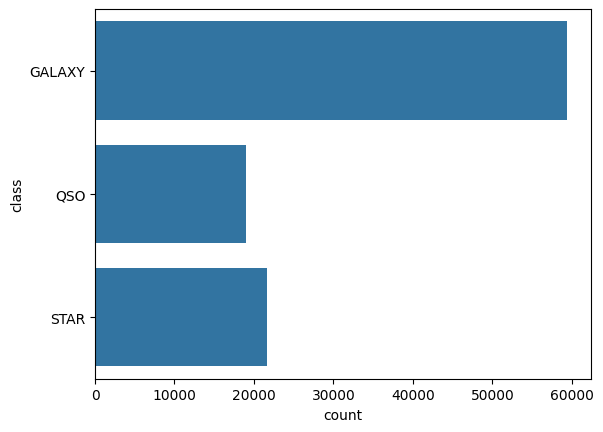

In [14]:
sns.countplot(dataset['class'])

# 3- preprocesssing data

In [15]:
drop_col = ['obj_ID','run_ID','rerun_ID','cam_col',
             'field_ID','spec_obj_ID','plate','MJD','fiber_ID']

dataset = dataset.drop(columns=drop_col)
dataset.head()

,alpha,delta,u,g,r,i,z,class,redshift
0,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,GALAXY,0.634794
1,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,GALAXY,0.779136
2,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,GALAXY,0.644195
3,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,GALAXY,0.932346
4,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,GALAXY,0.116123


In [16]:
dataset['class'].unique()

array(['GALAXY', 'QSO', 'STAR'], dtype=object)

In [17]:
dataset['class'] = dataset['class'].map({'GALAXY':0 , 'QSO':1 , 'STAR':2})
dataset.head()

,alpha,delta,u,g,r,i,z,class,redshift
0,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,0,0.634794
1,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,0,0.779136
2,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,0,0.644195
3,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,0,0.932346
4,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,0,0.116123


In [18]:
dataset['class'].unique()

array([0, 1, 2])

In [19]:
x = dataset.drop('class',axis=1).values
y = dataset['class'].values
x

array([[1.35689107e+02, 3.24946318e+01, 2.38788200e+01, ...,
        1.91657300e+01, 1.87937100e+01, 6.34793600e-01],
       [1.44826101e+02, 3.12741849e+01, 2.47775900e+01, ...,
        2.11681200e+01, 2.16142700e+01, 7.79136000e-01],
       [1.42188790e+02, 3.55824442e+01, 2.52630700e+01, ...,
        1.93485700e+01, 1.89482700e+01, 6.44194500e-01],
       ...,
       [2.24587407e+02, 1.57007074e+01, 2.11691600e+01, ...,
        1.76903400e+01, 1.73522100e+01, 1.43365600e-01],
       [2.12268621e+02, 4.66603653e+01, 2.53503900e+01, ...,
        1.90725400e+01, 1.86248200e+01, 4.55039600e-01],
       [1.96896053e+02, 4.94646428e+01, 2.26217100e+01, ...,
        2.00095900e+01, 1.92807500e+01, 5.42944200e-01]],
      shape=(100000, 8))

In [20]:
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2 , shuffle=True ,stratify=y,random_state=0)
print(y_train.shape)
print(y_test.shape)

(80000,)
(20000,)


In [21]:
sc_x = StandardScaler()
x_train = sc_x.fit_transform(x_train)
x_test = sc_x.transform(x_test)

# 4- design NN

In [22]:
multi_clas_model = Sequential([
    Input(shape=(x_train.shape[1],)),
    Dense(128 , activation='relu',kernel_regularizer=l1_l2(l1=0.001, l2=0.01)),
    Dense(64 , activation='relu',kernel_regularizer=l1_l2(l1=0.001, l2=0.01)),
    Dense(3 , activation='softmax')
])

# 5- prepartion NN to traning

In [23]:
# multi_clas_model.compile(optimizer='adam' , loss = 'cross_entropy' , metrics='f1_score')
multi_clas_model.compile(optimizer=Adam(learning_rate=0.001) , loss = 'sparse_categorical_crossentropy' , metrics=['accuracy'])


In [24]:
early_stoping = EarlyStopping(monitor='val_loss',
                              patience=5 , restore_best_weights=True )

In [25]:
#imbalance data  لحل ال 
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(weights))
print(class_weights)


{0: np.float64(0.5607424229680097), 1: np.float64(1.7579713011185092), 2: np.float64(1.5436565364206465)}


# 6- traning NN

In [26]:
history = multi_clas_model.fit(x_train , y_train ,
                     batch_size=128 , epochs=1000 , class_weight=class_weights,
                     validation_split=0.2 , callbacks=[early_stoping])

Epoch 1/1000
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8070 - loss: 0.8242 - val_accuracy: 0.8751 - val_loss: 0.4882
Epoch 2/1000
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9020 - loss: 0.4039 - val_accuracy: 0.9090 - val_loss: 0.4105
Epoch 3/1000
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9134 - loss: 0.3631 - val_accuracy: 0.9092 - val_loss: 0.3981
Epoch 4/1000
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9218 - loss: 0.3377 - val_accuracy: 0.9295 - val_loss: 0.3559
Epoch 5/1000
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9255 - loss: 0.3198 - val_accuracy: 0.9199 - val_loss: 0.3557
Epoch 6/1000
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9284 - loss: 0.3065 - val_accuracy: 0.9281 - val_loss: 0.3349
Epoch 7/1000
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9309 - loss: 0.2980 - val_accuracy: 0.9411 - val_loss: 0.3225
Epoch 8/1000
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9329 - loss: 0.2876 - 

In [27]:
multi_clas_model.evaluate(x_test, y_test)

625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9423 - loss: 0.2714


[0.27141907811164856, 0.942300021648407]

In [28]:
# test accuracy > train accuracy بفرق كبير  = datalaekge
# test acc مقارب ل train acc = generlaize
# test < train overfit

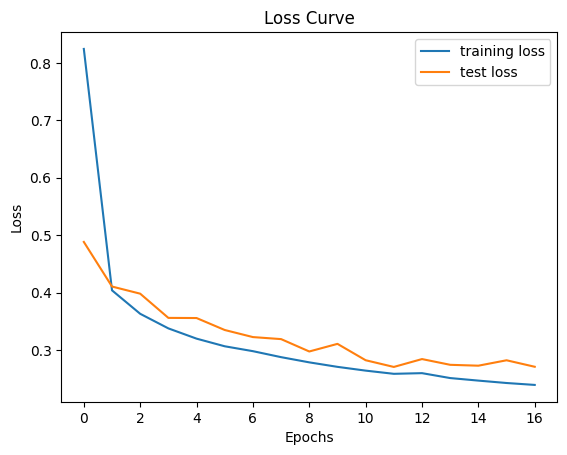

In [29]:
plt.plot(history.history['loss'] , label = 'training loss')
plt.plot(history.history['val_loss'] , label = 'test loss')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [30]:
np.set_printoptions(suppress=True, precision=2)
y_pred = multi_clas_model.predict(x_test)
print(y_pred)

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[[0.95 0.05 0.  ]
 [0.03 0.   0.97]
 [0.05 0.   0.95]
 ...
 [0.79 0.21 0.  ]
 [0.03 0.   0.96]
 [0.96 0.03 0.01]]


In [31]:
df_pred = pd.DataFrame(y_pred, columns=['Class0','Class1','Class2'])
print(df_pred.round(2))

       Class0  Class1  Class2
0        0.95    0.05    0.00
1        0.03    0.00    0.97
2        0.05    0.00    0.95
3        0.54    0.02    0.44
4        0.03    0.00    0.97
...       ...     ...     ...
19995    0.94    0.03    0.03
19996    0.17    0.01    0.82
19997    0.79    0.21    0.00
19998    0.03    0.00    0.96
19999    0.96    0.03    0.01

[20000 rows x 3 columns]


In [32]:
# convert probabilty class to hard class
y_pred_classes = np.argmax(y_pred, axis=1)
y_pred_classes

array([0, 2, 2, ..., 0, 2, 0], shape=(20000,))

[[11165   221   503]
 [  421  3365     6]
 [    0     3  4316]]


Text(50.722222222222214, 0.5, 'acual')

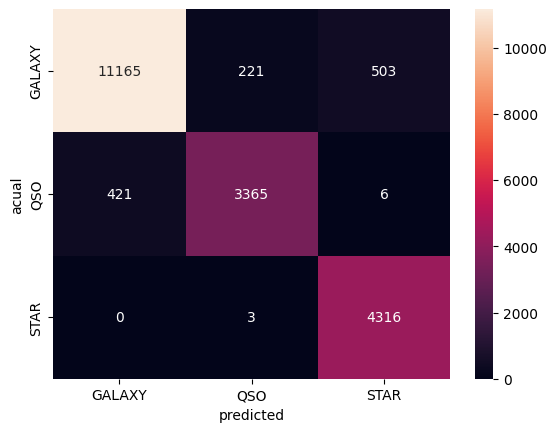

In [33]:

print(confusion_matrix(y_test, y_pred_classes))
cm = confusion_matrix(y_test, y_pred_classes)
sns.heatmap(cm , annot=True , fmt='d',
            xticklabels=['GALAXY','QSO','STAR'],
            yticklabels=['GALAXY','QSO','STAR'])
plt.xlabel('predicted')
plt.ylabel('acual')

In [34]:
print(classification_report(y_test , y_pred_classes,target_names=["GALAXY", "QSO", "STAR"]))
# Recall STAR = 100%  ليس بسبب خطأ في الموديل
#              بل لأن النجوم سهلة التمييز فيزيائياً ✅


              precision    recall  f1-score   support

      GALAXY       0.96      0.94      0.95     11889
         QSO       0.94      0.89      0.91      3792
        STAR       0.89      1.00      0.94      4319

    accuracy                           0.94     20000
   macro avg       0.93      0.94      0.94     20000
weighted avg       0.94      0.94      0.94     20000



In [35]:
print(f"GALAXY → STAR: {cm[0][2]}")
print(f"QSO    → STAR: {cm[1][2]}")

GALAXY → STAR: 503
QSO    → STAR: 6
